In [1]:
import pandas as pd
df = pd.read_csv("../csv/stockbit_reviews.csv")
df.head()

,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,cd03ac23-1db9-410e-86b7-d7cc0cc0b876,Clara Waves,Tolong itu CS Debora Utami direvaluasi. Pandua...,1,0,NaN,2026-03-05 20:56:59,"Halo kak Clara Waves,\n\nKami informasikan bah...",2026-03-06 10:00:52
1,c6fc70bb-c466-405a-8b71-efda8a92e633,Luthfi,Apa mengaktifkan debugging itu kejahatan? Upda...,1,0,3.19.3,2026-03-05 16:16:09,"Halo kak, terkait kendala tersebut silakan kak...",2026-03-06 08:46:01
2,9a9aff94-9d31-4c9e-9fd6-8a4aaf1f339f,Husni Aditya,tidak bisa digunakan setelah update terakhir,1,0,3.19.3,2026-03-05 09:17:37,"Halo kak Husni Aditya,\n\nTerkait kendala yang...",2026-03-05 09:49:36
3,88fdde71-c270-41e4-9a98-6b0106fc4803,Reyhan Ahmad Pragiwaka,tidak bisa membuka chart. sudah clear cache da...,3,0,3.19.3,2026-03-05 07:34:05,"Halo kak, terkait kendala tersebut mohon pasti...",2026-03-05 09:19:21
4,0ee18853-0362-4e08-b8e6-22289b9334b7,Walter Walter,ok,5,0,3.19.2,2026-03-04 17:17:34,"Hello,\n\nWe’re so happy to read your positive...",2026-03-05 08:42:17


In [2]:
# Cek kolom yang tersedia
print("Kolom yang tersedia:")
print(df.columns.tolist())
print(f"\nTotal review: {len(df)}")
df.info()

Kolom yang tersedia:
['reviewId', 'userName', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt']

Total review: 6973
<class 'pandas.DataFrame'>
RangeIndex: 6973 entries, 0 to 6972
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   reviewId              6973 non-null   str  
 1   userName              6973 non-null   str  
 2   content               6972 non-null   str  
 3   score                 6973 non-null   int64
 4   thumbsUpCount         6973 non-null   int64
 5   reviewCreatedVersion  6215 non-null   str  
 6   at                    6973 non-null   str  
 7   replyContent          4927 non-null   str  
 8   repliedAt             4927 non-null   str  
dtypes: int64(2), str(7)
memory usage: 490.4 KB


In [3]:
# Konversi datetime dan pilih kolom yang relevan
df["at"] = pd.to_datetime(df["at"])

# Pilih hanya kolom yang diperlukan (sesuaikan dengan kolom yang tersedia)
# Kolom umum: reviewId, content, score, at, userName, dll.
df = df[["reviewId", "content", "score", "at"]].copy()

df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 6973 entries, 0 to 6972
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   reviewId  6973 non-null   str           
 1   content   6972 non-null   str           
 2   score     6973 non-null   int64         
 3   at        6973 non-null   datetime64[us]
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 218.0 KB


,reviewId,content,score,at
0,cd03ac23-1db9-410e-86b7-d7cc0cc0b876,Tolong itu CS Debora Utami direvaluasi. Pandua...,1,2026-03-05 20:56:59
1,c6fc70bb-c466-405a-8b71-efda8a92e633,Apa mengaktifkan debugging itu kejahatan? Upda...,1,2026-03-05 16:16:09
2,9a9aff94-9d31-4c9e-9fd6-8a4aaf1f339f,tidak bisa digunakan setelah update terakhir,1,2026-03-05 09:17:37
3,88fdde71-c270-41e4-9a98-6b0106fc4803,tidak bisa membuka chart. sudah clear cache da...,3,2026-03-05 07:34:05
4,0ee18853-0362-4e08-b8e6-22289b9334b7,ok,5,2026-03-04 17:17:34


## Preprocessing - Indonesian Reviews

In [4]:
# Deteksi bahasa menggunakan heuristik sederhana atau anggap semua sebagai bahasa Indonesia
# Untuk Stockbit (aplikasi Indonesia), sebagian besar review akan dalam bahasa Indonesia
# Kita akan proses semua review sebagai bahasa Indonesia

df_id = df.copy()
print(f"Jumlah review: {len(df_id)}")
df_id["score"].value_counts().sort_index()

Jumlah review: 6973


score
1    1601
2     316
3     370
4     571
5    4115
Name: count, dtype: int64

In [5]:
def label_sentiment(score):
    if score <= 2:
        return "negatif"
    elif score == 3:
        return "neutral"
    else:
        return "positif"

df_id["sentiment"] = df_id["score"].apply(label_sentiment)
df_id["sentiment"].value_counts()

sentiment
positif    4686
negatif    1917
neutral     370
Name: count, dtype: int64

In [6]:
import re
import string

def remove_emoji(text):
    emoji_pattern = re.compile("[" 
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', str(text))

def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

# Bikin salinan hanya kolom yang dipakai
df_text = df_id[["reviewId", "content", "score", "sentiment"]].copy()

# 1. Hapus emoji (paling awal, sebelum lowercase)
df_text["clean_text"] = df_text["content"].apply(remove_emoji)

# Ubah ke lowercase
df_text["clean_text"] = df_text["clean_text"].str.lower()

# 2. Hapus tanda baca (setelah lowercase, sebelum normalisasi slang)
df_text["clean_text"] = df_text["clean_text"].apply(remove_punctuation)

# Hapus URL
df_text["clean_text"] = df_text["clean_text"].apply(
    lambda x: re.sub(r"http\S+|www\S+", "", x)
)

# Hapus karakter non-huruf (angka, simbol, tanda baca berlebihan)
df_text["clean_text"] = df_text["clean_text"].apply(
    lambda x: re.sub(r"[^a-zA-Záéíóúüñçàèìòùâêîôûäëïöü\s]", " ", x)
)

# Hapus spasi berlebih
df_text["clean_text"] = df_text["clean_text"].apply(
    lambda x: re.sub(r"\s+", " ", x).strip()
)

df_text["clean_text"] = df_text["clean_text"].fillna("")

# Lihat hasil beberapa contoh
df_text[["content", "clean_text"]].head(10)

,content,clean_text
0,Tolong itu CS Debora Utami direvaluasi. Pandua...,tolong itu cs debora utami direvaluasi panduan...
1,Apa mengaktifkan debugging itu kejahatan? Upda...,apa mengaktifkan debugging itu kejahatan updat...
2,tidak bisa digunakan setelah update terakhir,tidak bisa digunakan setelah update terakhir
3,tidak bisa membuka chart. sudah clear cache da...,tidak bisa membuka chart sudah clear cache dan...
4,ok,ok
5,Aplikasi terbaik sejauh ini untuk investor rit...,aplikasi terbaik sejauh ini untuk investor rit...
6,kalo bisa datafeed nya hilangin xixixi,kalo bisa datafeed nya hilangin xixixi
7,simply best stock broker in Indonesia,simply best stock broker in indonesia
8,ok,ok
9,bagus,bagus


In [7]:
slang_dict = {
    "ga": "tidak", "gak": "tidak", "nggak": "tidak", "ngga": "tidak",
    "gk": "tidak", "tdk": "tidak", "g": "tidak",
    "sy": "saya", "aku": "saya", "gue": "saya", "gw": "saya",
    "lu": "kamu", "lo": "kamu", "elu": "kamu",
    "km": "kamu", "kamu": "kamu",
    "udh": "sudah", "udah": "sudah", "dah": "sudah",
    "blm": "belum", "blum": "belum",
    "bgt": "banget", "bngt": "banget",
    "yg": "yang", "yng": "yang",
    "dgn": "dengan", "dg": "dengan",
    "utk": "untuk", "tuk": "untuk",
    "jg": "juga", "jga": "juga",
    "sdh": "sudah", "sdng": "sedang",
    "krn": "karena", "karna": "karena",
    "bisa": "bisa", "bs": "bisa",
    "dr": "dari", "dri": "dari",
    "di": "di", "dlm": "dalam",
    "emg": "memang", "emang": "memang",
    "gimana": "bagaimana", "gmna": "bagaimana",
    "aja": "saja", "aj": "saja",
    "dpt": "dapat", "dpat": "dapat",
    "mau": "mau", "mo": "mau",
    "skrg": "sekarang", "skrang": "sekarang",
    "trs": "terus", "trus": "terus",
    "pengen": "ingin", "pgn": "ingin",
    "klo": "kalau", "kl": "kalau", "kalo": "kalau",
    "tp": "tapi", "tpi": "tapi",
    "apk": "aplikasi", "app": "aplikasi",
    "lg": "lagi", "lgi": "lagi",
    "nih": "ini", "ni": "ini",
    "itu": "itu", "tu": "itu",
    "hbs": "habis", "abis": "habis",
    "jgn": "jangan",
    "msh": "masih", "msih": "masih",
    "bnyk": "banyak", "bnyak": "banyak",
    "pke": "pakai", "pkai": "pakai", "make": "pakai",
    "sampe": "sampai", "smpe": "sampai",
    "knp": "kenapa", "knapa": "kenapa",
    "napa": "kenapa",
}

def normalize_slang(text):
    words = text.split()
    normalized = [slang_dict.get(word, word) for word in words]
    return " ".join(normalized)

df_text["clean_text"] = df_text["clean_text"].apply(normalize_slang)
df_text[["content", "clean_text"]].head(10)

,content,clean_text
0,Tolong itu CS Debora Utami direvaluasi. Pandua...,tolong itu cs debora utami direvaluasi panduan...
1,Apa mengaktifkan debugging itu kejahatan? Upda...,apa mengaktifkan debugging itu kejahatan updat...
2,tidak bisa digunakan setelah update terakhir,tidak bisa digunakan setelah update terakhir
3,tidak bisa membuka chart. sudah clear cache da...,tidak bisa membuka chart sudah clear cache dan...
4,ok,ok
5,Aplikasi terbaik sejauh ini untuk investor rit...,aplikasi terbaik sejauh ini untuk investor rit...
6,kalo bisa datafeed nya hilangin xixixi,kalau bisa datafeed nya hilangin xixixi
7,simply best stock broker in Indonesia,simply best stock broker in indonesia
8,ok,ok
9,bagus,bagus


In [8]:
!pip install nltk
import nltk

# Unduh resource yang diperlukan
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.tokenize import word_tokenize

# Hapus stopword
stopwords_id_en = set([
    "dan", "yang", "di", "ke", "dari", "untuk", "ini", "itu", "saya", "aku",
    "the", "is", "am", "are", "to", "in", "on", "of", "for", "this", "that"
])

def preprocess_tokens(text):
    # 1. Tokenisasi
    tokens = word_tokenize(text)
    # 2. Buang stopwords
    tokens = [t for t in tokens if t.lower() not in stopwords_id_en]
    return tokens

# Lakukan di kolom clean_text
df_text["tokens"] = df_text["clean_text"].apply(preprocess_tokens)

# Lihat contoh
df_text[["clean_text", "tokens"]].head(10)


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Emriqurrizal\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Emriqurrizal\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,clean_text,tokens
0,tolong itu cs debora utami direvaluasi panduan...,"[tolong, cs, debora, utami, direvaluasi, pandu..."
1,apa mengaktifkan debugging itu kejahatan updat...,"[apa, mengaktifkan, debugging, kejahatan, upda..."
2,tidak bisa digunakan setelah update terakhir,"[tidak, bisa, digunakan, setelah, update, tera..."
3,tidak bisa membuka chart sudah clear cache dan...,"[tidak, bisa, membuka, chart, sudah, clear, ca..."
4,ok,[ok]
5,aplikasi terbaik sejauh ini untuk investor rit...,"[aplikasi, terbaik, sejauh, investor, ritel, u..."
6,kalau bisa datafeed nya hilangin xixixi,"[kalau, bisa, datafeed, nya, hilangin, xixixi]"
7,simply best stock broker in indonesia,"[simply, best, stock, broker, indonesia]"
8,ok,[ok]
9,bagus,[bagus]


In [9]:
!pip install PySastrawi

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stem_tokens(tokens):
    return [stemmer.stem(word) for word in tokens]

df_text["tokens"] = df_text["tokens"].apply(stem_tokens)

# Perbarui clean_text juga dari tokens hasil stemming
df_text["clean_text"] = df_text["tokens"].apply(lambda x: " ".join(x))


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


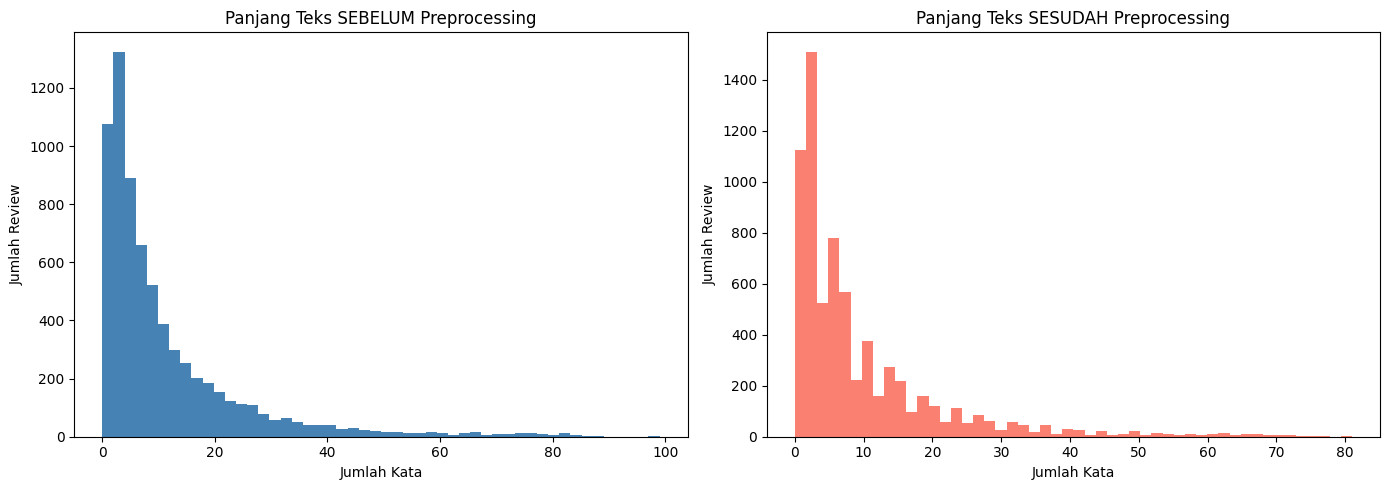

In [10]:
!pip install matplotlib

import matplotlib.pyplot as plt

df_text["original_length"] = df_text["content"].fillna("").str.split().apply(len)
df_text["clean_length"] = df_text["clean_text"].fillna("").str.split().apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_text["original_length"], bins=50, color="steelblue")
axes[0].set_title("Panjang Teks SEBELUM Preprocessing")
axes[0].set_xlabel("Jumlah Kata")
axes[0].set_ylabel("Jumlah Review")

axes[1].hist(df_text["clean_length"], bins=50, color="salmon")
axes[1].set_title("Panjang Teks SESUDAH Preprocessing")
axes[1].set_xlabel("Jumlah Kata")
axes[1].set_ylabel("Jumlah Review")

plt.tight_layout()
plt.show()


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


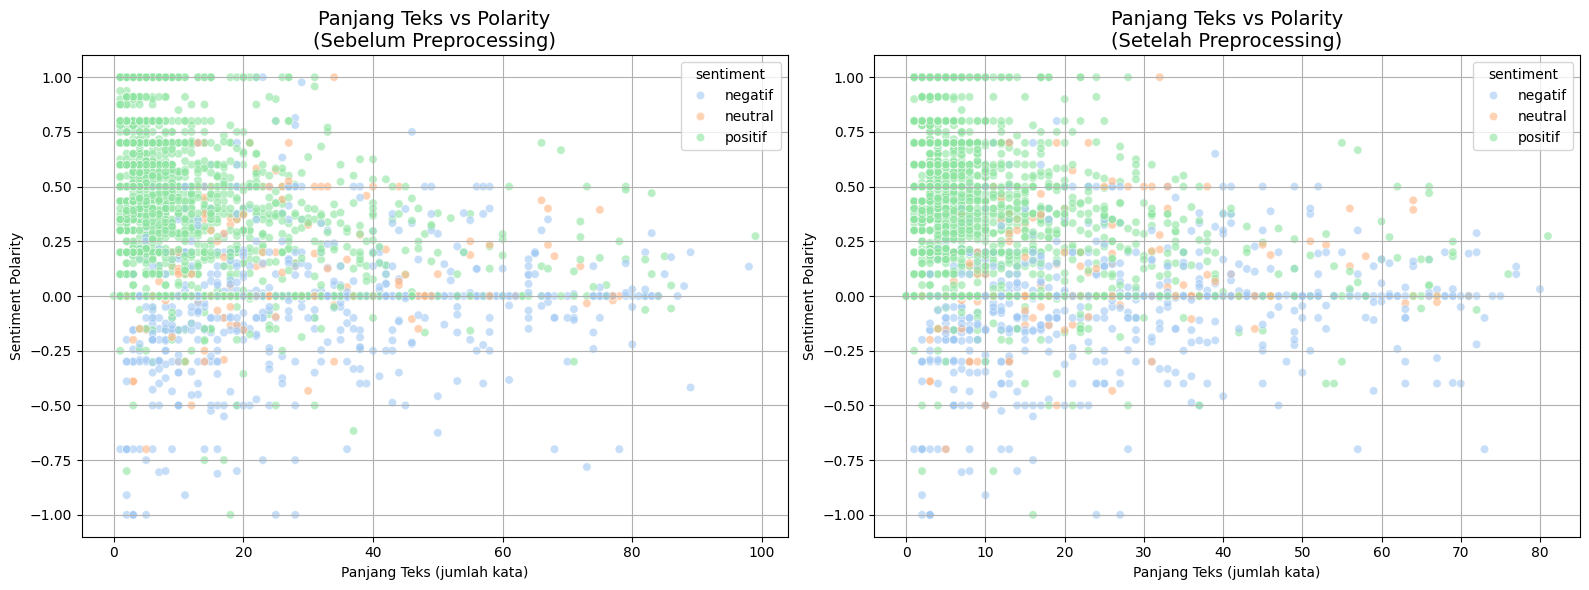

In [11]:
!pip install textblob seaborn

from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung polarity dari teks asli dan teks bersih
df_text['polarity_before'] = df_text['content'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
df_text['polarity_after']  = df_text['clean_text'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot SEBELUM preprocessing
sns.scatterplot(
    data=df_text, ax=axes[0],
    x='original_length',
    y='polarity_before',
    hue='sentiment',
    palette='pastel',
    edgecolor='white',
    alpha=0.6
)
axes[0].set_title('Panjang Teks vs Polarity\n(Sebelum Preprocessing)', fontsize=14)
axes[0].set_xlabel('Panjang Teks (jumlah kata)')
axes[0].set_ylabel('Sentiment Polarity')
axes[0].grid(True)

# Plot SESUDAH preprocessing
sns.scatterplot(
    data=df_text, ax=axes[1],
    x='clean_length',
    y='polarity_after',
    hue='sentiment',
    palette='pastel',
    edgecolor='white',
    alpha=0.6
)
axes[1].set_title('Panjang Teks vs Polarity\n(Setelah Preprocessing)', fontsize=14)
axes[1].set_xlabel('Panjang Teks (jumlah kata)')
axes[1].set_ylabel('Sentiment Polarity')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [12]:
# Simpan data yang sudah dipreproses
df_text.to_csv("../csv/stockbit_preprocessing_id.csv", index=False)

In [14]:
# Ringkasan
print("Distribusi sentimen:")
print(df_text["sentiment"].value_counts())
print("\nPersentase:")
print(df_text["sentiment"].value_counts(normalize=True) * 100)
df_text.head()

Distribusi sentimen:
sentiment
positif    4686
negatif    2287
Name: count, dtype: int64

Persentase:
sentiment
positif    67.202065
negatif    32.797935
Name: proportion, dtype: float64


,reviewId,content,score,sentiment,clean_text,tokens,original_length,clean_length,polarity_before,polarity_after
0,cd03ac23-1db9-410e-86b7-d7cc0cc0b876,Tolong itu CS Debora Utami direvaluasi. Pandua...,1,negatif,tolong cs debora utami revaluasi pandu transak...,"[tolong, cs, debora, utami, revaluasi, pandu, ...",24,22,0.0,0.0
1,c6fc70bb-c466-405a-8b71-efda8a92e633,Apa mengaktifkan debugging itu kejahatan? Upda...,1,negatif,apa aktif debugging jahat update baru aplikasi...,"[apa, aktif, debugging, jahat, update, baru, a...",25,23,0.0,0.0
2,9a9aff94-9d31-4c9e-9fd6-8a4aaf1f339f,tidak bisa digunakan setelah update terakhir,1,negatif,tidak bisa guna telah update akhir,"[tidak, bisa, guna, telah, update, akhir]",6,6,0.0,0.0
3,88fdde71-c270-41e4-9a98-6b0106fc4803,tidak bisa membuka chart. sudah clear cache da...,3,negatif,tidak bisa buka chart sudah clear cache reinst...,"[tidak, bisa, buka, chart, sudah, clear, cache...",11,10,0.1,0.1
4,0ee18853-0362-4e08-b8e6-22289b9334b7,ok,5,positif,ok,[ok],1,1,0.5,0.5
